In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Customer Sales Data Cleaning & Visualization Project

## Project Objective

The objective of this project is to clean, process, analyze, and visualize customer sales data.

This project demonstrates:

- Handling missing values
- Removing duplicate records
- Detecting and treating outliers
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization
- Extracting business insights

## Tools & Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [4]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import random
from faker import Faker

import warnings
warnings.filterwarnings("ignore")



fake = Faker()




sns.set_theme()

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Creating Raw Dataset

In this section, we create a realistic customer sales dataset.

The dataset contains:

- Customer information
- Product details
- Sales information
- Payment details
- Customer ratings

To simulate a real-world scenario, we will intentionally introduce:

- Missing values
- Duplicate records
- Outliers

These issues will be handled during the data cleaning process.

In [5]:
# Set random seed for reproducibility

np.random.seed(42)


# Number of records

number_of_records = 1000


# Generate Customer IDs

customer_ids = range(1001, 1001 + number_of_records)


# Generate customer names

names = [
    fake.name()
    for i in range(number_of_records)
]


# Generate ages

ages = np.random.randint(
    18,
    60,
    number_of_records
)


# Generate genders

genders = np.random.choice(
    ["Male", "Female"],
    number_of_records
)


# Generate cities

cities = np.random.choice(
    [
        "Delhi",
        "Mumbai",
        "Bangalore",
        "Chennai",
        "Pune",
        "Hyderabad"
    ],
    number_of_records
)


# Generate product categories

categories = np.random.choice(
    [
        "Electronics",
        "Clothing",
        "Home",
        "Beauty",
        "Sports"
    ],
    number_of_records
)


# Generate product names

products = np.random.choice(
    [
        "Laptop",
        "Mobile",
        "Shoes",
        "Watch",
        "Headphones",
        "Camera",
        "T-Shirt",
        "Bag"
    ],
    number_of_records
)


# Quantity purchased

quantity = np.random.randint(
    1,
    6,
    number_of_records
)


# Product price

price = np.random.randint(
    500,
    50000,
    number_of_records
)


# Total sales

total_sales = quantity * price


# Payment mode

payment_mode = np.random.choice(
    [
        "UPI",
        "Credit Card",
        "Debit Card",
        "Cash"
    ],
    number_of_records
)


# Customer rating

rating = np.random.randint(
    1,
    6,
    number_of_records
)


# Purchase dates

purchase_date = pd.date_range(
    start="2025-01-01",
    periods=number_of_records,
    freq="D"
)

In [6]:
# Create DataFrame

df = pd.DataFrame({

    "Customer_ID": customer_ids,
    "Customer_Name": names,
    "Age": ages,
    "Gender": genders,
    "City": cities,
    "Product_Category": categories,
    "Product_Name": products,
    "Quantity": quantity,
    "Price": price,
    "Total_Sales": total_sales,
    "Payment_Mode": payment_mode,
    "Purchase_Date": purchase_date,
    "Rating": rating

})


# Display first 5 rows

df.head()

,Customer_ID,Customer_Name,Age,Gender,City,Product_Category,Product_Name,Quantity,Price,Total_Sales,Payment_Mode,Purchase_Date,Rating
0,1001,Bruce Obrien,56,Male,Delhi,Home,Bag,1,23738,23738,UPI,2025-01-01,1
1,1002,Robert Boyd,46,Male,Delhi,Beauty,Laptop,1,22389,22389,Cash,2025-01-02,4
2,1003,Michael Lynch,32,Female,Chennai,Beauty,T-Shirt,3,30813,92439,UPI,2025-01-03,2
3,1004,Marvin Hernandez,25,Female,Delhi,Home,Laptop,2,33035,66070,UPI,2025-01-04,4
4,1005,Antonio Boyd,38,Male,Hyderabad,Electronics,Bag,3,49399,148197,UPI,2025-01-05,5


In [7]:
# Check dataset size

df.shape

(1000, 13)

In [8]:
# Adding missing values intentionally

missing_columns = [
    "Age",
    "City",
    "Rating",
    "Payment_Mode"
]


for col in missing_columns:

    indexes = np.random.choice(
        df.index,
        size=30,
        replace=False
    )

    df.loc[indexes, col] = np.nan


print("Missing values added successfully!")

Missing values added successfully!


In [9]:
# Count missing values

df.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
Age,30
Gender,0
City,30
Product_Category,0
Product_Name,0
Quantity,0
Price,0
Total_Sales,0


In [10]:
# Adding duplicate rows

duplicate_rows = df.sample(
    20,
    random_state=42
)


df = pd.concat(
    [
        df,
        duplicate_rows
    ],
    ignore_index=True
)


print("Duplicate rows added!")

Duplicate rows added!


In [11]:
df.shape

(1020, 13)

In [12]:
# Adding extreme sales values

outlier_indexes = np.random.choice(
    df.index,
    size=5,
    replace=False
)


df.loc[
    outlier_indexes,
    "Total_Sales"
] = 5000000


print("Outliers added successfully!")

Outliers added successfully!


In [13]:
# Save raw dataset

df.to_csv(
    "raw_customer_sales.csv",
    index=False
)


print("Raw dataset saved!")

Raw dataset saved!


In [14]:
df.head()

,Customer_ID,Customer_Name,Age,Gender,City,Product_Category,Product_Name,Quantity,Price,Total_Sales,Payment_Mode,Purchase_Date,Rating
0,1001,Bruce Obrien,56.0,Male,Delhi,Home,Bag,1,23738,23738,UPI,2025-01-01,1.0
1,1002,Robert Boyd,46.0,Male,Delhi,Beauty,Laptop,1,22389,22389,Cash,2025-01-02,4.0
2,1003,Michael Lynch,32.0,Female,Chennai,Beauty,T-Shirt,3,30813,92439,UPI,2025-01-03,2.0
3,1004,Marvin Hernandez,25.0,Female,Delhi,Home,Laptop,2,33035,66070,UPI,2025-01-04,4.0
4,1005,Antonio Boyd,38.0,Male,Hyderabad,Electronics,Bag,3,49399,148197,UPI,2025-01-05,5.0


# 2. Data Understanding

Before cleaning the dataset, we analyze the structure and quality of the raw data.

We will check:

- Number of rows and columns
- Data types
- Missing values
- Statistical information

In [15]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Customer_ID       1020 non-null   int64         
 1   Customer_Name     1020 non-null   object        
 2   Age               990 non-null    float64       
 3   Gender            1020 non-null   object        
 4   City              989 non-null    object        
 5   Product_Category  1020 non-null   object        
 6   Product_Name      1020 non-null   object        
 7   Quantity          1020 non-null   int64         
 8   Price             1020 non-null   int64         
 9   Total_Sales       1020 non-null   int64         
 10  Payment_Mode      989 non-null    object        
 11  Purchase_Date     1020 non-null   datetime64[ns]
 12  Rating            990 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usage: 103.7+ KB


In [16]:
# Display first 5 rows

df.head()

,Customer_ID,Customer_Name,Age,Gender,City,Product_Category,Product_Name,Quantity,Price,Total_Sales,Payment_Mode,Purchase_Date,Rating
0,1001,Bruce Obrien,56.0,Male,Delhi,Home,Bag,1,23738,23738,UPI,2025-01-01,1.0
1,1002,Robert Boyd,46.0,Male,Delhi,Beauty,Laptop,1,22389,22389,Cash,2025-01-02,4.0
2,1003,Michael Lynch,32.0,Female,Chennai,Beauty,T-Shirt,3,30813,92439,UPI,2025-01-03,2.0
3,1004,Marvin Hernandez,25.0,Female,Delhi,Home,Laptop,2,33035,66070,UPI,2025-01-04,4.0
4,1005,Antonio Boyd,38.0,Male,Hyderabad,Electronics,Bag,3,49399,148197,UPI,2025-01-05,5.0


In [17]:
# Statistical summary of numerical columns

df.describe()

,Customer_ID,Age,Quantity,Price,Total_Sales,Purchase_Date,Rating
count,1020.000000,990.000000,1020.00000,1020.000000,1.020000e+03,1020,990.000000
mean,1502.918627,38.830303,3.04902,25191.627451,1.007260e+05,2026-05-17 22:02:49.411764736,2.962626
min,1001.000000,18.000000,1.00000,566.000000,5.660000e+02,2025-01-01 00:00:00,1.000000
25%,1253.750000,28.000000,2.00000,13198.000000,3.035850e+04,2025-09-10 18:00:00,2.000000
50%,1505.500000,40.000000,3.00000,24928.500000,6.261850e+04,2026-05-20 12:00:00,3.000000
75%,1752.250000,50.000000,4.00000,37859.750000,1.088662e+05,2027-01-22 06:00:00,4.000000
max,2000.000000,59.000000,5.00000,49923.000000,5.000000e+06,2027-09-27 00:00:00,5.000000
std,288.735731,12.166501,1.40710,14377.998826,3.491548e+05,NaN,1.405470


In [18]:
# Count missing values

df.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
Age,30
Gender,0
City,31
Product_Category,0
Product_Name,0
Quantity,0
Price,0
Total_Sales,0


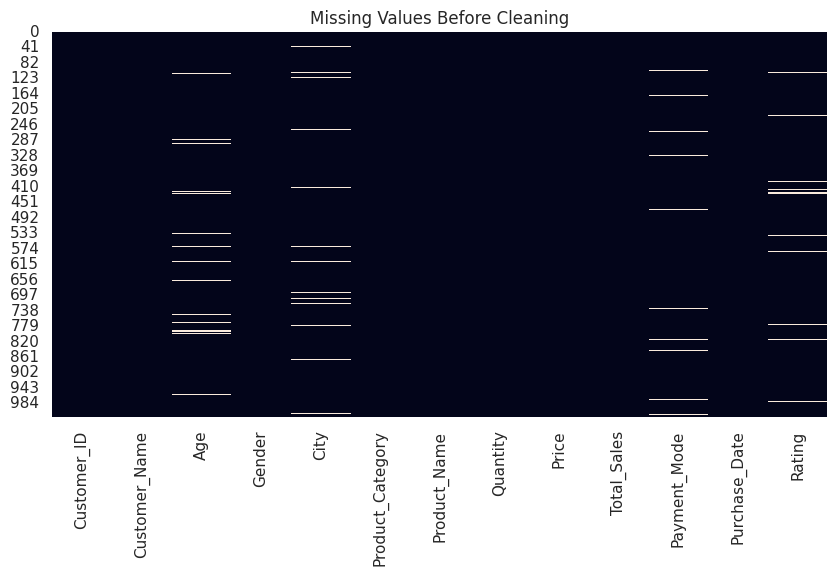

In [19]:
# Visualize missing values

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Before Cleaning")

plt.show()

In [20]:
# Fill numerical missing values

df["Age"].fillna(
    df["Age"].median(),
    inplace=True
)


df["Rating"].fillna(
    df["Rating"].median(),
    inplace=True
)

In [21]:
# Fill categorical missing values

df["City"].fillna(
    df["City"].mode()[0],
    inplace=True
)


df["Payment_Mode"].fillna(
    df["Payment_Mode"].mode()[0],
    inplace=True
)

In [22]:
# Check missing values again

df.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product_Category,0
Product_Name,0
Quantity,0
Price,0
Total_Sales,0


In [23]:
# Count duplicate rows

df.duplicated().sum()

np.int64(19)

In [24]:
# Remove duplicate rows

df.drop_duplicates(
    inplace=True
)

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.shape

(1001, 13)

# 3. Outlier Detection & Treatment

Outliers are extreme values that differ significantly from normal observations.

In this project, we use the IQR (Interquartile Range) method to detect and remove extreme values from the Total_Sales column.

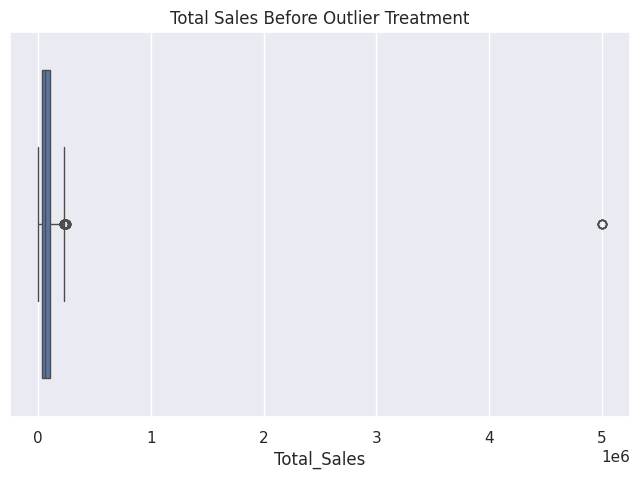

In [27]:
# Boxplot before removing outliers

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Total_Sales"]
)

plt.title("Total Sales Before Outlier Treatment")

plt.show()

In [28]:
# Calculate Q1 and Q3

Q1 = df["Total_Sales"].quantile(0.25)

Q3 = df["Total_Sales"].quantile(0.75)


# Calculate IQR

IQR = Q3 - Q1


print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

Q1: 30363.0
Q3: 109254.0
IQR: 78891.0


Lower Limit = Q1 - 1.5 × IQR

Upper Limit = Q3 + 1.5 × IQR

In [29]:
# Calculate lower and upper limits

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR


print("Lower Limit:", lower_limit)

print("Upper Limit:", upper_limit)

Lower Limit: -87973.5
Upper Limit: 227590.5


In [30]:
# Count outliers

outliers = df[
    (df["Total_Sales"] < lower_limit) |
    (df["Total_Sales"] > upper_limit)
]


print(
    "Number of outliers:",
    len(outliers)
)

Number of outliers: 25


In [31]:
# Remove outliers

df = df[
    (df["Total_Sales"] >= lower_limit) &
    (df["Total_Sales"] <= upper_limit)
]

In [32]:
df.shape

(976, 13)

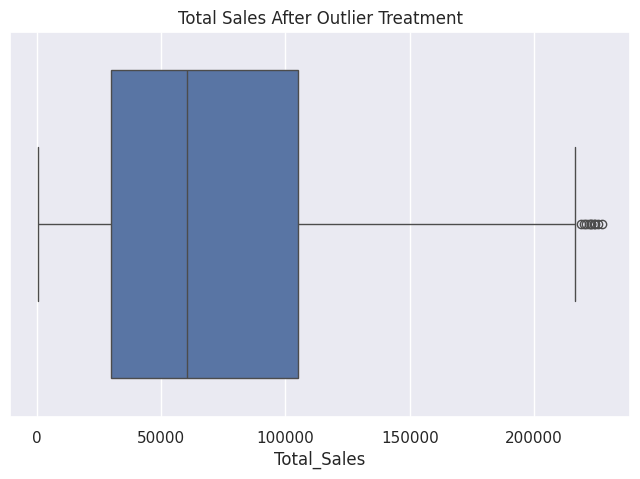

In [33]:
# Boxplot after removing outliers

plt.figure(figsize=(8,5))


sns.boxplot(
    x=df["Total_Sales"]
)


plt.title(
    "Total Sales After Outlier Treatment"
)


plt.show()

In [34]:
# Save cleaned dataset

df.to_csv(
    "cleaned_customer_sales.csv",
    index=False
)


print("Clean dataset saved successfully!")

Clean dataset saved successfully!


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, relationships, and important insights from the cleaned dataset.

In this section, we analyze:

- Sales performance
- Customer behavior
- Product trends
- Payment preferences
- Data relationships

In [35]:
# Display cleaned dataset

df.head()

,Customer_ID,Customer_Name,Age,Gender,City,Product_Category,Product_Name,Quantity,Price,Total_Sales,Payment_Mode,Purchase_Date,Rating
0,1001,Bruce Obrien,56.0,Male,Delhi,Home,Bag,1,23738,23738,UPI,2025-01-01,1.0
1,1002,Robert Boyd,46.0,Male,Delhi,Beauty,Laptop,1,22389,22389,Cash,2025-01-02,4.0
2,1003,Michael Lynch,32.0,Female,Chennai,Beauty,T-Shirt,3,30813,92439,UPI,2025-01-03,2.0
3,1004,Marvin Hernandez,25.0,Female,Delhi,Home,Laptop,2,33035,66070,UPI,2025-01-04,4.0
4,1005,Antonio Boyd,38.0,Male,Hyderabad,Electronics,Bag,3,49399,148197,UPI,2025-01-05,5.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 1005
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Customer_ID       976 non-null    int64         
 1   Customer_Name     976 non-null    object        
 2   Age               976 non-null    float64       
 3   Gender            976 non-null    object        
 4   City              976 non-null    object        
 5   Product_Category  976 non-null    object        
 6   Product_Name      976 non-null    object        
 7   Quantity          976 non-null    int64         
 8   Price             976 non-null    int64         
 9   Total_Sales       976 non-null    int64         
 10  Payment_Mode      976 non-null    object        
 11  Purchase_Date     976 non-null    datetime64[ns]
 12  Rating            976 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(6)
memory usage: 106.8+ KB


In [37]:
# Calculate sales by category

category_sales = df.groupby(
    "Product_Category"
)["Total_Sales"].sum().sort_values(
    ascending=False
)


category_sales

,Total_Sales
Product_Category,
Beauty,16700695
Electronics,14944968
Home,14676158
Sports,14276477
Clothing,11232829


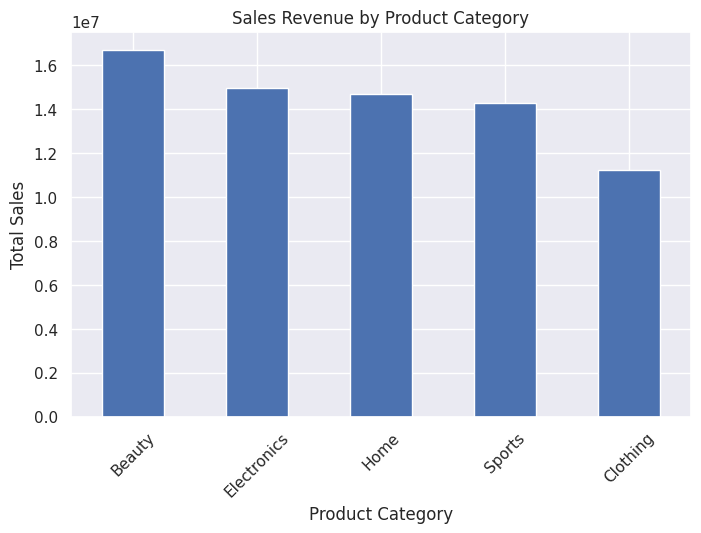

In [38]:
plt.figure(figsize=(8,5))


category_sales.plot(
    kind="bar"
)


plt.title(
    "Sales Revenue by Product Category"
)

plt.xlabel(
    "Product Category"
)

plt.ylabel(
    "Total Sales"
)


plt.xticks(rotation=45)

plt.show()

In [39]:
city_sales = df.groupby(
    "City"
)["Total_Sales"].sum().sort_values(
    ascending=False
)


city_sales

,Total_Sales
City,
Chennai,14540002
Delhi,12623612
Hyderabad,11858804
Mumbai,11507459
Pune,10928624
Bangalore,10372626


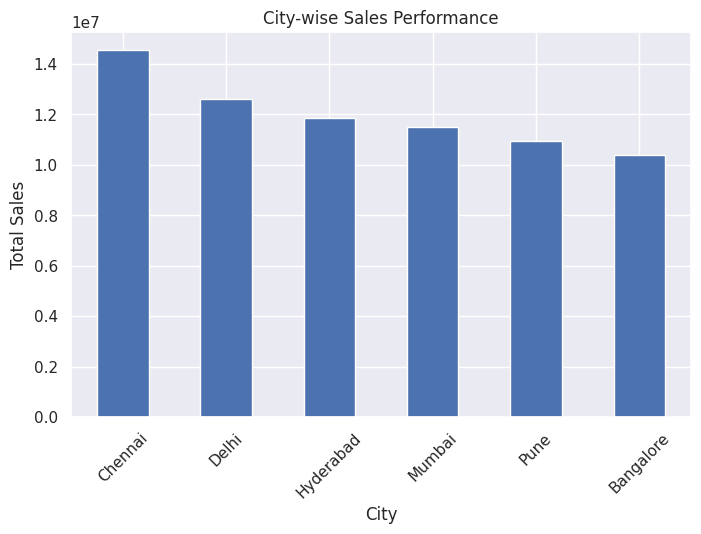

In [40]:
plt.figure(figsize=(8,5))


city_sales.plot(
    kind="bar"
)


plt.title(
    "City-wise Sales Performance"
)


plt.xlabel(
    "City"
)


plt.ylabel(
    "Total Sales"
)


plt.xticks(rotation=45)

plt.show()

In [41]:
gender_count = df["Gender"].value_counts()


gender_count

,count
Gender,
Male,507
Female,469


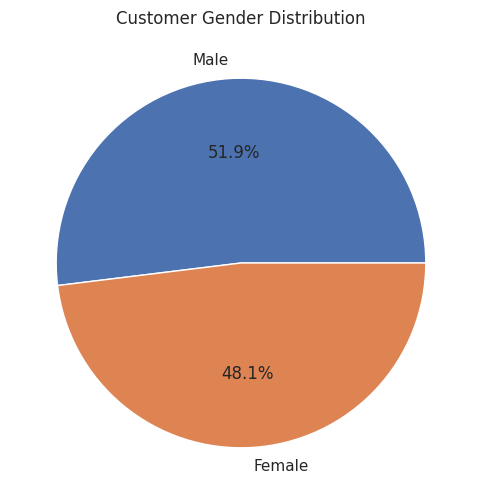

In [42]:
plt.figure(figsize=(6,6))


gender_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)


plt.title(
    "Customer Gender Distribution"
)


plt.ylabel("")


plt.show()

In [43]:
payment_count = df[
    "Payment_Mode"
].value_counts()


payment_count

,count
Payment_Mode,
Credit Card,295
UPI,239
Cash,235
Debit Card,207


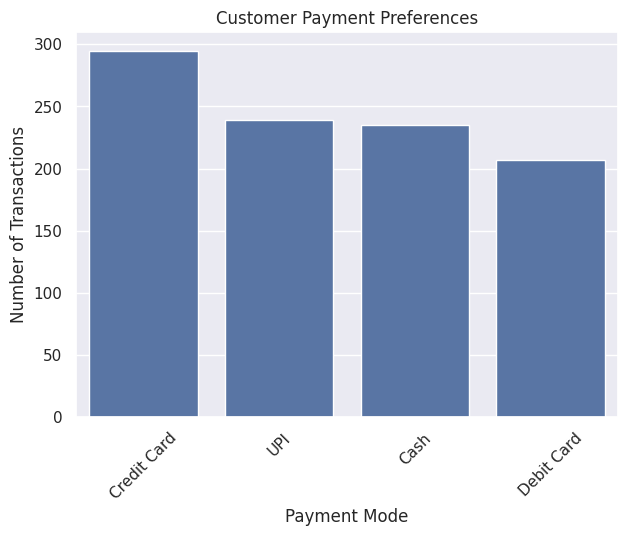

In [44]:
plt.figure(figsize=(7,5))


sns.barplot(
    x=payment_count.index,
    y=payment_count.values
)


plt.title(
    "Customer Payment Preferences"
)


plt.xlabel(
    "Payment Mode"
)


plt.ylabel(
    "Number of Transactions"
)


plt.xticks(rotation=45)

plt.show()

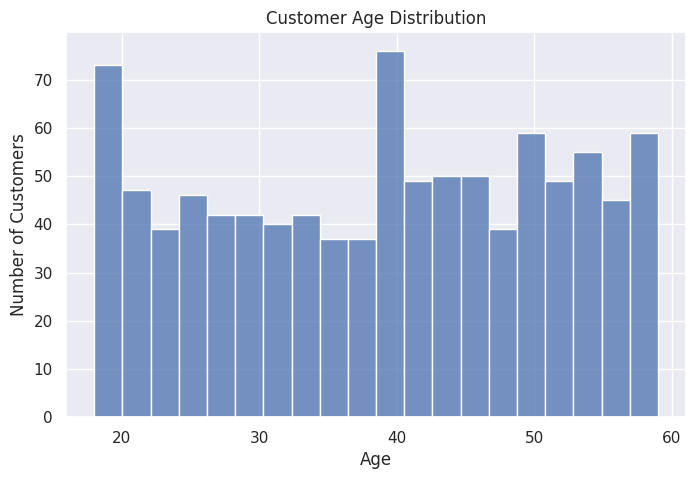

In [45]:
plt.figure(figsize=(8,5))


sns.histplot(
    df["Age"],
    bins=20
)


plt.title(
    "Customer Age Distribution"
)


plt.xlabel(
    "Age"
)


plt.ylabel(
    "Number of Customers"
)


plt.show()

# 5. Advanced Data Visualization

In this section, we analyze product performance, customer ratings, and relationships between numerical variables.

The objective is to identify important business patterns from the cleaned dataset.

In [46]:
# Calculate sales by product

product_sales = df.groupby(
    "Product_Name"
)["Total_Sales"].sum().sort_values(
    ascending=False
)


product_sales

,Total_Sales
Product_Name,
Shoes,10094421
Laptop,9935856
Watch,9140022
Camera,8994958
Mobile,8820782
Headphones,8782684
T-Shirt,8151372
Bag,7911032


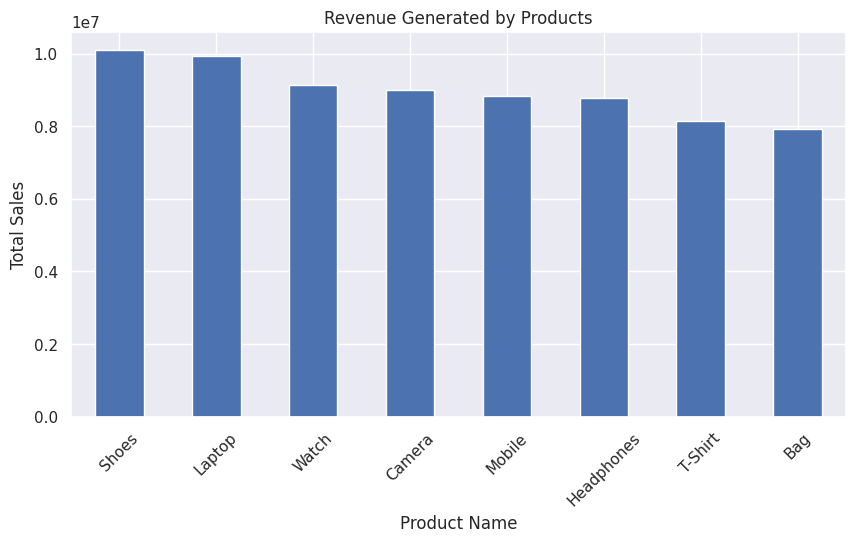

In [47]:
plt.figure(figsize=(10,5))


product_sales.plot(
    kind="bar"
)


plt.title(
    "Revenue Generated by Products"
)


plt.xlabel(
    "Product Name"
)


plt.ylabel(
    "Total Sales"
)


plt.xticks(rotation=45)

plt.show()

In [48]:
quantity_analysis = df.groupby(
    "Product_Name"
)["Quantity"].sum().sort_values(
    ascending=False
)


quantity_analysis

,Quantity
Product_Name,
Shoes,421
Laptop,400
Headphones,386
Watch,370
T-Shirt,351
Camera,345
Mobile,344
Bag,328


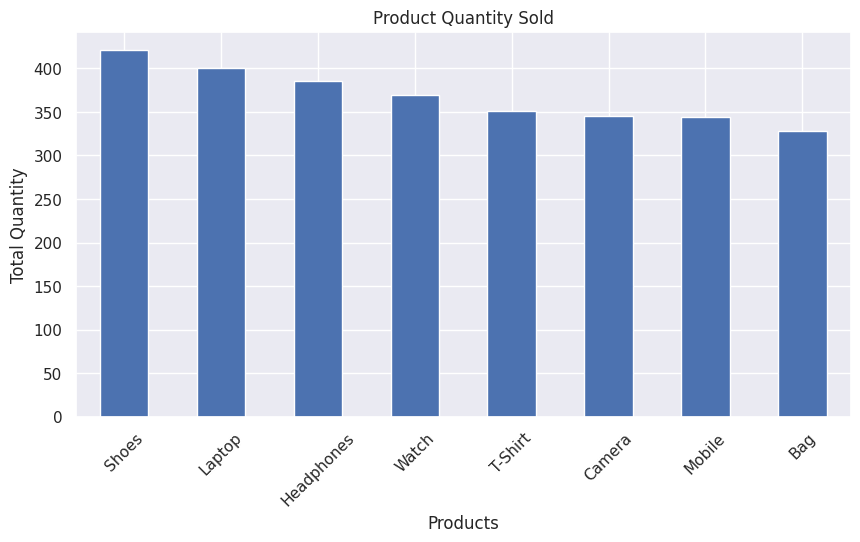

In [49]:
plt.figure(figsize=(10,5))


quantity_analysis.plot(
    kind="bar"
)


plt.title(
    "Product Quantity Sold"
)


plt.xlabel(
    "Products"
)


plt.ylabel(
    "Total Quantity"
)


plt.xticks(rotation=45)

plt.show()

In [50]:
rating_distribution = df[
    "Rating"
].value_counts().sort_index()


rating_distribution

,count
Rating,
1.0,184
2.0,217
3.0,212
4.0,173
5.0,190


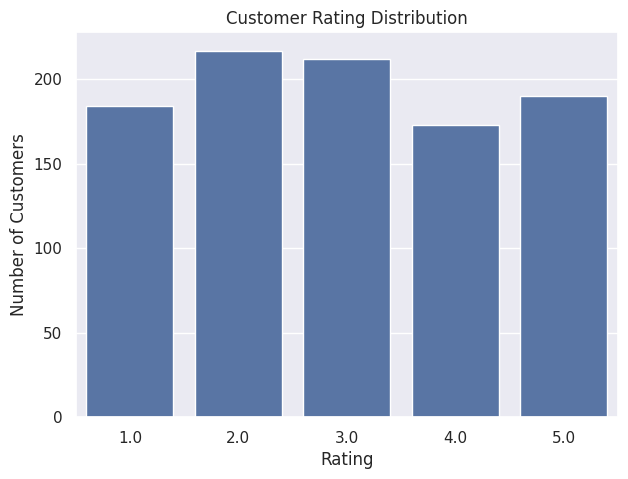

In [51]:
plt.figure(figsize=(7,5))


sns.barplot(
    x=rating_distribution.index,
    y=rating_distribution.values
)


plt.title(
    "Customer Rating Distribution"
)


plt.xlabel(
    "Rating"
)


plt.ylabel(
    "Number of Customers"
)


plt.show()

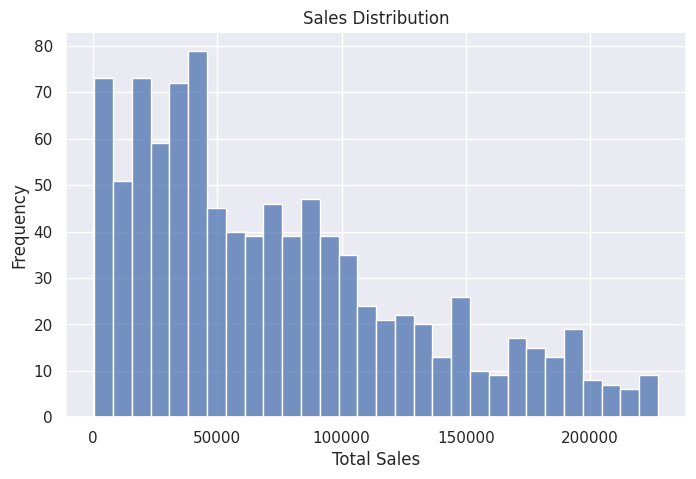

In [52]:
plt.figure(figsize=(8,5))


sns.histplot(
    df["Total_Sales"],
    bins=30
)


plt.title(
    "Sales Distribution"
)


plt.xlabel(
    "Total Sales"
)


plt.ylabel(
    "Frequency"
)


plt.show()

In [53]:
# Select numerical columns

numeric_data = df[
    [
        "Age",
        "Quantity",
        "Price",
        "Total_Sales",
        "Rating"
    ]
]


numeric_data.corr()

,Age,Quantity,Price,Total_Sales,Rating
Age,1.000000,-0.016500,0.038900,0.015585,-0.028421
Quantity,-0.016500,1.000000,-0.061492,0.562524,-0.011888
Price,0.038900,-0.061492,1.000000,0.713817,0.022784
Total_Sales,0.015585,0.562524,0.713817,1.000000,-0.001622
Rating,-0.028421,-0.011888,0.022784,-0.001622,1.000000


# 6. Business Insights

After analyzing the cleaned customer sales dataset, the following insights were obtained from the visualizations.

## Key Findings:

1. Product categories show different levels of revenue contribution. The highest-performing category represents the major source of sales.

2. Certain cities contribute more revenue compared to others, indicating stronger customer demand in those regions.

3. Customers use multiple payment methods, with digital payment methods showing strong adoption.

4. Customer ratings provide information about customer satisfaction and product experience.

5. Product-wise analysis helps identify the best-performing products based on revenue and quantity sold.

6. Correlation analysis helps understand relationships between numerical variables such as quantity, price, and total sales.

# Business Recommendations

Based on the analysis:

- Focus marketing strategies on high-performing product categories.

- Improve inventory planning for products with high demand.

- Target high-performing cities with personalized offers.

- Encourage digital payment methods for smoother transactions.

- Analyze customer feedback to improve product quality and satisfaction.

# Conclusion

This project demonstrated the complete data analytics workflow, including data generation, cleaning, preprocessing, exploratory data analysis, and visualization.

The dataset was cleaned by handling missing values, removing duplicate records, and treating outliers.

Various visualizations were created to identify sales patterns, customer behavior, product performance, and business trends.

The analysis helps transform raw data into meaningful insights that can support better business decisions.

In [54]:
# Save final cleaned dataset

df.to_csv(
    "cleaned_customer_sales.csv",
    index=False
)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [55]:
from google.colab import files

files.download("raw_customer_sales.csv")

files.download("cleaned_customer_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>